In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM processed_air_quality",
    conn
)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,15,17,Friday
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,16,17,Friday
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,18,17,Friday


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         290 non-null    int64  
 1   timestamp  290 non-null    object 
 2   aqi        290 non-null    int64  
 3   pm2_5      290 non-null    float64
 4   pm10       290 non-null    float64
 5   co         290 non-null    float64
 6   no2        290 non-null    float64
 7   o3         290 non-null    float64
 8   so2        290 non-null    float64
 9   hour       290 non-null    int64  
 10  day        290 non-null    int64  
 11  weekday    290 non-null    object 
dtypes: float64(6), int64(4), object(2)
memory usage: 27.3+ KB


In [5]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
count,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000
mean,145.500000,3.103448,40.674448,46.189586,605.766586,14.631931,53.012793,6.477793,17.168966,15.875862
std,83.860002,0.942823,20.286700,23.377907,245.465816,7.952892,34.202536,1.675684,4.614075,9.629743
min,1.000000,1.000000,7.140000,8.460000,248.980000,1.890000,0.220000,2.820000,0.000000,1.000000
25%,73.250000,3.000000,27.380000,30.110000,385.995000,8.347500,25.740000,5.220000,14.000000,7.000000
50%,145.500000,3.000000,37.330000,40.355000,584.180000,14.185000,50.605000,6.465000,18.000000,18.000000
75%,217.750000,4.000000,54.415000,62.230000,748.375000,19.667500,73.500000,7.625000,21.000000,24.000000
max,290.000000,5.000000,97.470000,119.310000,1310.840000,31.780000,146.150000,12.520000,23.000000,31.000000


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 290
Columns: 12


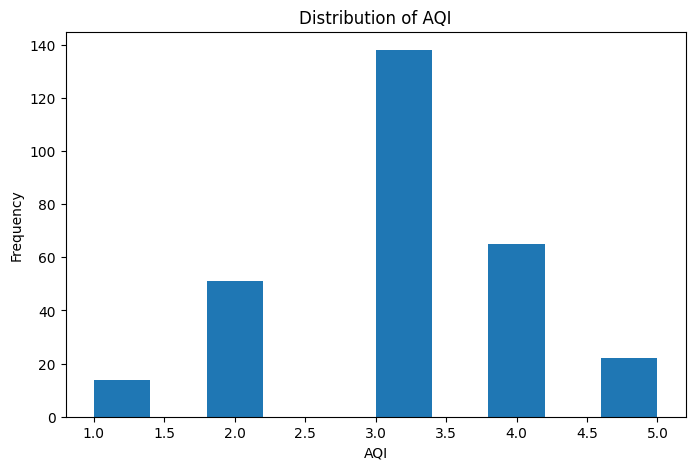

In [7]:
#aqi distribution
plt.figure(figsize=(8,5))

plt.hist(df["aqi"], bins=10)

plt.title("Distribution of AQI")

plt.xlabel("AQI")

plt.ylabel("Frequency")

plt.show()

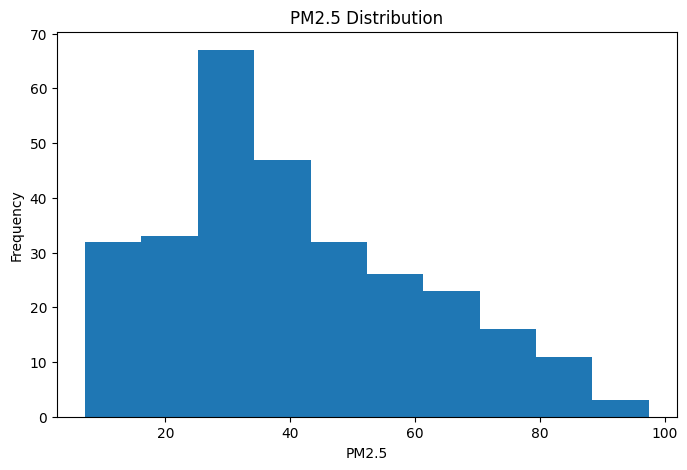

In [8]:
#PM 2.5 distribution
plt.figure(figsize=(8,5))

plt.hist(df["pm2_5"], bins=10)

plt.title("PM2.5 Distribution")

plt.xlabel("PM2.5")

plt.ylabel("Frequency")

plt.show()

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

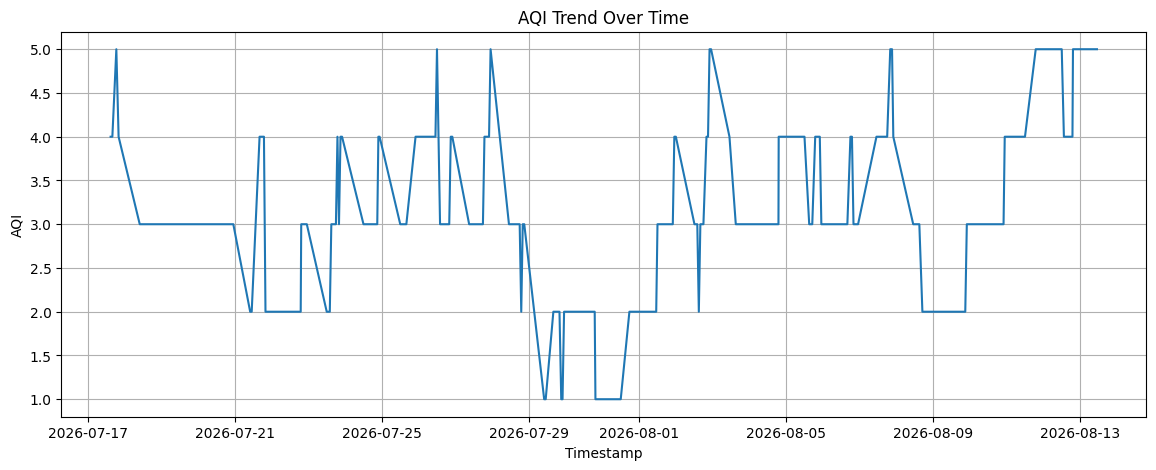

In [10]:
#AQI trend over time
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["aqi"])

plt.title("AQI Trend Over Time")

plt.xlabel("Timestamp")

plt.ylabel("AQI")

plt.grid(True)

plt.show()

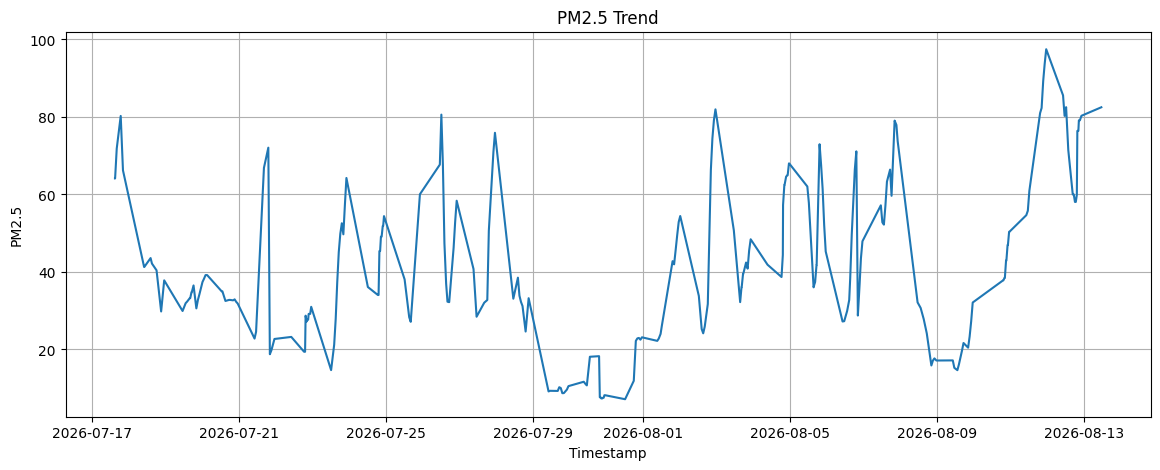

In [11]:
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["pm2_5"])

plt.title("PM2.5 Trend")

plt.xlabel("Timestamp")

plt.ylabel("PM2.5")

plt.grid(True)

plt.show()

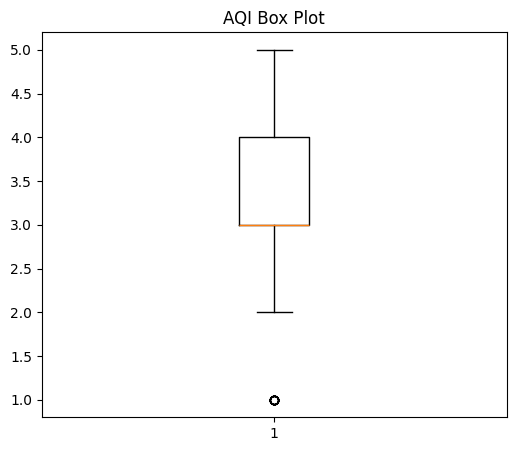

In [12]:
plt.figure(figsize=(6,5))

plt.boxplot(df["aqi"])

plt.title("AQI Box Plot")

plt.show()

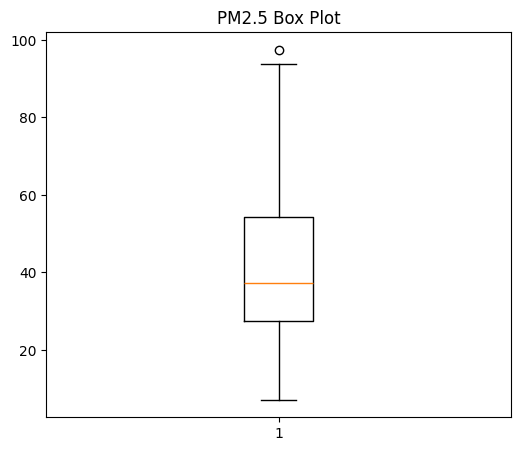

In [13]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm2_5"])

plt.title("PM2.5 Box Plot")

plt.show()

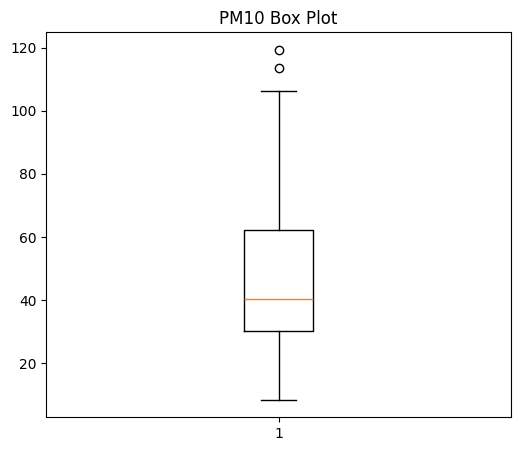

In [14]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm10"])

plt.title("PM10 Box Plot")

plt.show()

In [15]:
correlation = df.corr(numeric_only=True)

correlation

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
id,1.000000,0.221140,0.251618,0.275321,-0.035408,-0.129661,0.191906,0.223488,0.106090,-0.575678
aqi,0.221140,1.000000,0.942429,0.925777,0.524816,0.254661,0.182463,0.577323,0.039715,-0.382746
pm2_5,0.251618,0.942429,1.000000,0.989728,0.557643,0.277952,0.184373,0.638232,0.087475,-0.386968
pm10,0.275321,0.925777,0.989728,1.000000,0.609499,0.343653,0.105990,0.690788,0.157128,-0.390677
co,-0.035408,0.524816,0.557643,0.609499,1.000000,0.890230,-0.652902,0.726330,0.137836,-0.397359
no2,-0.129661,0.254661,0.277952,0.343653,0.890230,1.000000,-0.825591,0.670570,0.230496,-0.233947
o3,0.191906,0.182463,0.184373,0.105990,-0.652902,-0.825591,1.000000,-0.329399,-0.116077,0.141356
so2,0.223488,0.577323,0.638232,0.690788,0.726330,0.670570,-0.329399,1.000000,0.293183,-0.332080
hour,0.106090,0.039715,0.087475,0.157128,0.137836,0.230496,-0.116077,0.293183,1.000000,0.036374
day,-0.575678,-0.382746,-0.386968,-0.390677,-0.397359,-0.233947,0.141356,-0.332080,0.036374,1.000000


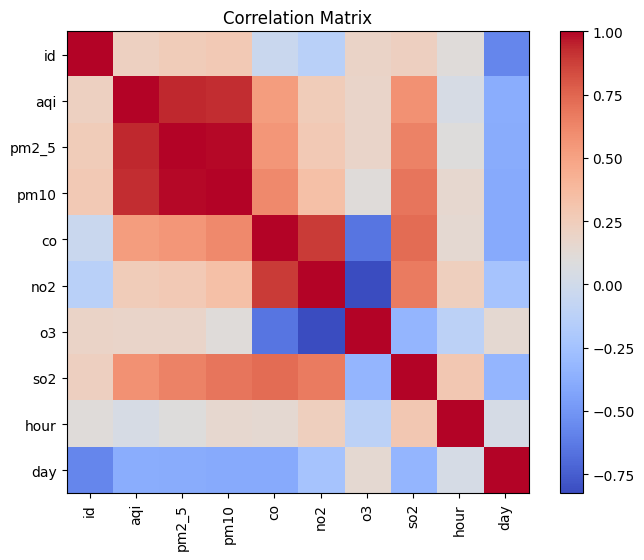

In [16]:
#correlation heatmap
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

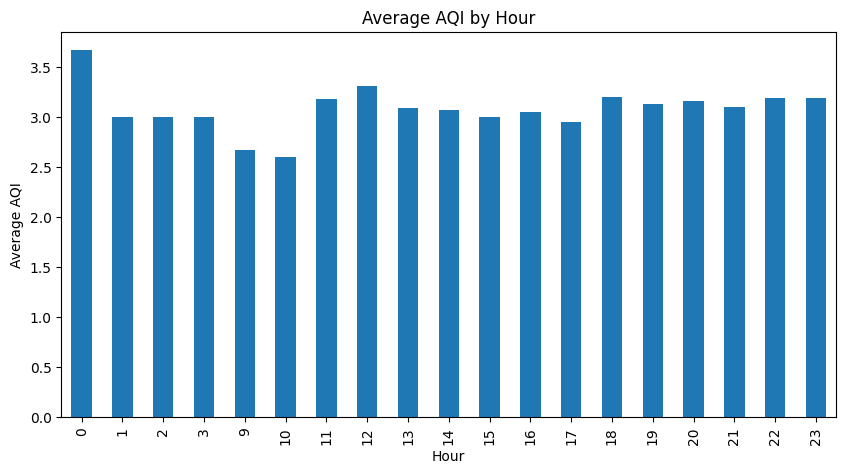

In [17]:
#avg aqi by hour
hourly = df.groupby("hour")["aqi"].mean()

hourly.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Hour")

plt.xlabel("Hour")

plt.ylabel("Average AQI")

plt.show()

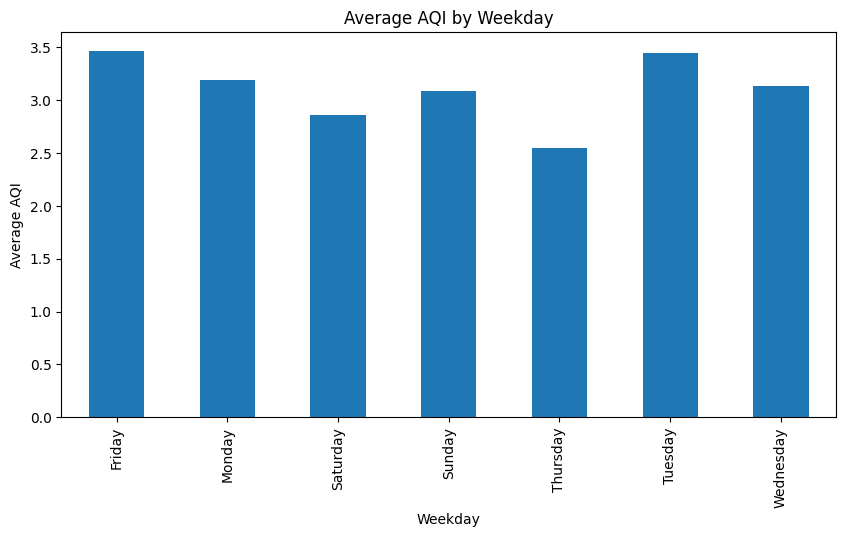

In [18]:
weekday = df.groupby("weekday")["aqi"].mean()

weekday.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Average AQI")

plt.show()

In [19]:
summary = df.describe()

summary.to_csv("../data/eda_summary.csv")

In [20]:
conn.close()